# Projet de business décisionnel
## Analyse de la rentabilité d'un projet de vente

Ce notebook présente une analyse réalisée avant le lancement d'un projet de vente de desserts faits maison.
L'objectif est de modéliser la rentabilité théorique des produits afin d'orienter les décisions de production.

## 1. Contexte du projet

Le projet consiste à vendre des desserts faits maison (cups et cookies) pendant un mois, avec une production artisanale réalisée par une seule personne.

Les principales contraintes identifiées sont :
- le temps de production,
- la capacité limitée,
- la conservation courte des produits,
- des contraintes horaires variables.

## 2. Objectifs de l'analyse

Cette analyse vise à répondre aux questions suivantes :

- Quels produits sont les plus rentables ?
- Quel produit génère le plus de marge par heure de travail ?
- La box découverte est-elle pertinente économiquement ?
- Comment prioriser la production en cas de temps limité ?

L'analyse repose sur plusieurs hypothèses simplificatrices :

- les coûts unitaires sont estimés et considérés comme constants,
- les temps de préparation sont des moyennes,
- la demande est supposée suffisante pour écouler la production,
- les coûts indirects (électricité, transport, communication) ne sont pas pris en compte.

Ces hypothèses permettent de se concentrer sur la rentabilité opérationnelle des produits.

In [16]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

## 3. Données utilisées

Les données utilisées sont des données construites, basées sur des estimations réalistes de coûts, de temps de préparation et de prix de vente.

In [17]:
df = pd.DataFrame({
    "id_produit": [1, 2, 3, 4, 5],
    "nom_produit": [
        "Strawberry Crunch Cup (moyenne)",
        "Strawberry Crunch Cup (grande)",
        "Cookie Crunch Cup",
        "Cookie Cup",
        "Box Découverte"
    ],
    "categorie": ["cup", "cup", "cookie", "cookie", "box"],
    "temps_preparation_min": [10, 10, 20, 15, 40],
    "cout_unitaire": [2.70, 3.85, 1.90, 1.40, 7.30],
    "prix_vente": [6.00, 8.00, 6.00, 4.00, 13.00]
})

## 4. Vérification et aperçu des données

Avant toute analyse, on vérifie que les données ont bien été créées et on obtient un premier aperçu de leur structure.

In [18]:
df.head()

,id_produit,nom_produit,categorie,temps_preparation_min,cout_unitaire,prix_vente
0,1,Strawberry Crunch Cup (moyenne),cup,10,2.70,6.0
1,2,Strawberry Crunch Cup (grande),cup,10,3.85,8.0
2,3,Cookie Crunch Cup,cookie,20,1.90,6.0
3,4,Cookie Cup,cookie,15,1.40,4.0
4,5,Box Découverte,box,40,7.30,13.0


La fonction `describe()` fournit un aperçu statistique rapide de toutes les variables numériques : valeurs min, max, moyenne et quartiles. Elle permet de vérifier la cohérence des données avant de commencer l'analyse.

In [19]:
df.describe()

,id_produit,temps_preparation_min,cout_unitaire,prix_vente
count,5.000000,5.0000,5.000000,5.000000
mean,3.000000,19.0000,3.430000,7.400000
std,1.581139,12.4499,2.353083,3.435113
min,1.000000,10.0000,1.400000,4.000000
25%,2.000000,10.0000,1.900000,6.000000
50%,3.000000,15.0000,2.700000,6.000000
75%,4.000000,20.0000,3.850000,8.000000
max,5.000000,40.0000,7.300000,13.000000


## 5. Calcul des indicateurs de rentabilité

### 5.1 Marge brute

La marge brute correspond à la différence entre le prix de vente et le coût de production unitaire.

**Marge brute = Prix de vente − Coût unitaire**

In [20]:
df["marge_brute"] = df["prix_vente"] - df["cout_unitaire"]
df

,id_produit,nom_produit,categorie,temps_preparation_min,cout_unitaire,prix_vente,marge_brute
0,1,Strawberry Crunch Cup (moyenne),cup,10,2.70,6.0,3.30
1,2,Strawberry Crunch Cup (grande),cup,10,3.85,8.0,4.15
2,3,Cookie Crunch Cup,cookie,20,1.90,6.0,4.10
3,4,Cookie Cup,cookie,15,1.40,4.0,2.60
4,5,Box Découverte,box,40,7.30,13.0,5.70


La Box Découverte présente la marge brute unitaire la plus haute (5,70 €), devant les Strawberry Crunch Cups.
Cependant, la marge brute seule ne suffit pas à prioriser la production : elle ne tient pas compte du temps nécessaire à la fabrication de chaque produit.

### 5.2 Taux de marge

Le taux de marge exprime la marge brute en pourcentage du prix de vente. Il permet de comparer les produits sur une base relative, indépendamment de leur prix de vente.

**Taux de marge = (Marge brute / Prix de vente) × 100**

In [21]:
df["taux_marge"] = (df["marge_brute"] / df["prix_vente"]) * 100
df[["nom_produit", "prix_vente", "marge_brute", "taux_marge"]]

,nom_produit,prix_vente,marge_brute,taux_marge
0,Strawberry Crunch Cup (moyenne),6.0,3.30,55.000000
1,Strawberry Crunch Cup (grande),8.0,4.15,51.875000
2,Cookie Crunch Cup,6.0,4.10,68.333333
3,Cookie Cup,4.0,2.60,65.000000
4,Box Découverte,13.0,5.70,43.846154


Le Cookie Cup affiche le taux de marge le plus élevé (65 %), ce qui signifie que 65 % de son prix de vente constitue de la marge nette.
La Box Découverte, malgré sa marge brute unitaire la plus haute, présente le taux de marge le plus bas (43,8 %).

Ce résultat montre que marge absolue et marge relative ne donnent pas le même classement.

**Visualisation — Taux de marge par produit (%)**

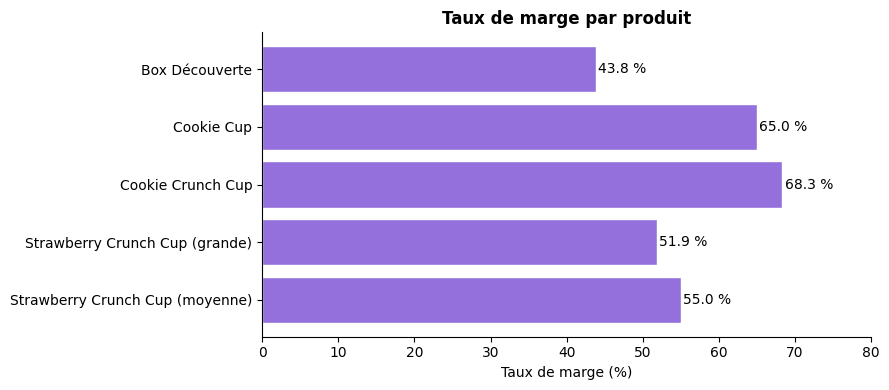

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(df["nom_produit"], df["taux_marge"], color="mediumpurple", edgecolor="white")

for idx, val in enumerate(df["taux_marge"]):
    ax.text(val + 0.3, idx, f"{val:.1f} %", va="center", fontsize=10)

ax.set_xlabel("Taux de marge (%)")
ax.set_title("Taux de marge par produit", fontweight="bold")
ax.set_xlim(0, 80)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 5.3 Marge par minute

La marge par minute rapporte la marge brute au temps de production unitaire. Elle constitue une étape intermédiaire vers le calcul de la marge horaire.

In [23]:
df["marge_par_minute"] = df["marge_brute"] / df["temps_preparation_min"]
df[["nom_produit", "temps_preparation_min", "marge_brute", "marge_par_minute"]]

,nom_produit,temps_preparation_min,marge_brute,marge_par_minute
0,Strawberry Crunch Cup (moyenne),10,3.30,0.330000
1,Strawberry Crunch Cup (grande),10,4.15,0.415000
2,Cookie Crunch Cup,20,4.10,0.205000
3,Cookie Cup,15,2.60,0.173333
4,Box Découverte,40,5.70,0.142500


### 5.4 Marge par heure

La marge par heure permet de comparer les produits comme un revenu horaire. C'est l'indicateur central de cette analyse, car il intègre à la fois la marge générée et le temps mobilisé pour la produire.

**Marge par heure = Marge par minute × 60**

In [24]:
df["marge_par_heure"] = df["marge_par_minute"] * 60
df[["nom_produit", "marge_brute", "marge_par_heure"]]

,nom_produit,marge_brute,marge_par_heure
0,Strawberry Crunch Cup (moyenne),3.30,19.80
1,Strawberry Crunch Cup (grande),4.15,24.90
2,Cookie Crunch Cup,4.10,12.30
3,Cookie Cup,2.60,10.40
4,Box Découverte,5.70,8.55


La marge par heure met en évidence des écarts importants entre les produits. Les Strawberry Crunch Cups génèrent la marge horaire la plus élevée, devant les cookies et la Box Découverte.

Dans un contexte de production individuelle, cet indicateur est déterminant pour prioriser les produits lorsque le temps disponible est limité.

**Visualisation — Marge par heure par produit**

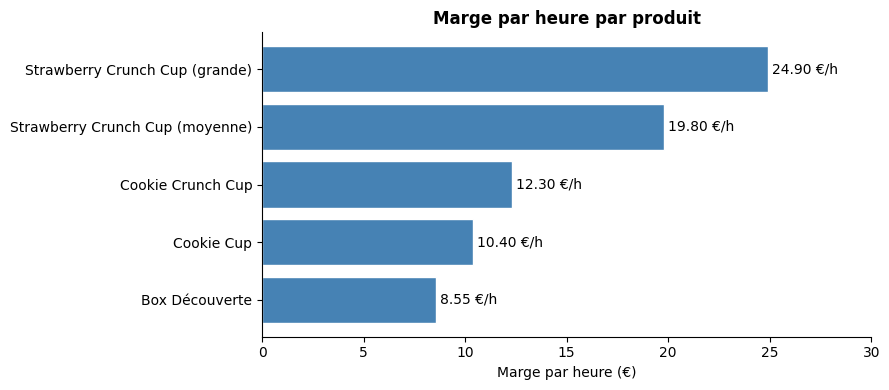

In [25]:
df_sorted = df.sort_values(by="marge_par_heure", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(df_sorted["nom_produit"], df_sorted["marge_par_heure"], color="steelblue", edgecolor="white")

for idx, val in enumerate(df_sorted["marge_par_heure"]):
    ax.text(val + 0.2, idx, f"{val:.2f} €/h", va="center", fontsize=10)

ax.set_xlabel("Marge par heure (€)")
ax.set_title("Marge par heure par produit", fontweight="bold")
ax.set_xlim(0, 30)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Analyse décisionnelle

### 6.1 Classement des produits par marge horaire

À partir des indicateurs calculés, on classe les produits par ordre de rentabilité horaire décroissante.

In [26]:
df.sort_values(by="marge_par_heure", ascending=False)[
    ["nom_produit", "marge_brute", "taux_marge", "marge_par_heure"]
    ]

,nom_produit,marge_brute,taux_marge,marge_par_heure
1,Strawberry Crunch Cup (grande),4.15,51.875000,24.90
0,Strawberry Crunch Cup (moyenne),3.30,55.000000,19.80
2,Cookie Crunch Cup,4.10,68.333333,12.30
3,Cookie Cup,2.60,65.000000,10.40
4,Box Découverte,5.70,43.846154,8.55


### 6.2 Analyse par catégorie de produit

On regroupe les produits par catégorie (cup, cookie, box) pour comparer leur performance moyenne par famille de produits.

In [27]:
df.groupby("categorie")[["marge_brute", "taux_marge", "marge_par_heure"]].mean().round(2)

,marge_brute,taux_marge,marge_par_heure
categorie,,,
box,5.70,43.85,8.55
cookie,3.35,66.67,11.35
cup,3.72,53.44,22.35


Les cups présentent la marge horaire moyenne la plus élevée (22,35 €/h), devant les cookies (11,35 €/h) et la box (8,55 €/h).
Ce résultat confirme que la catégorie cup doit être prioritaire dans la stratégie de production.

### 6.3 Marge brute unitaire vs Marge par heure

Ce graphique met en évidence une différence clé : la marge brute unitaire et la marge horaire ne produisent pas le même classement.

La Box Découverte a la marge brute unitaire la plus haute (5,70 €) mais la marge horaire la plus basse (8,55 €/h), car son temps de préparation (40 min) est nettement supérieur aux autres produits.
C'est pourquoi la marge horaire est l'indicateur pertinent pour piloter la production.

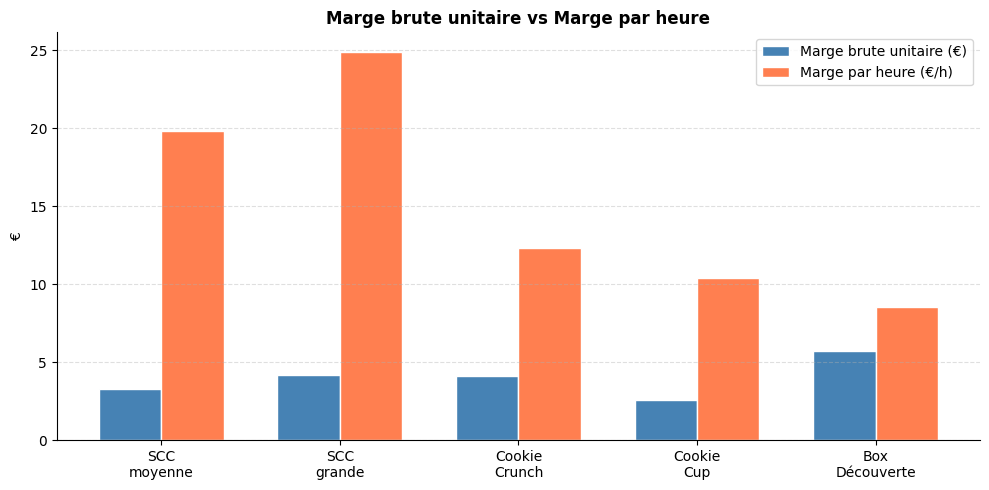

In [28]:
noms_courts = ["SCC\nmoyenne", "SCC\ngrande", "Cookie\nCrunch", "Cookie\nCup", "Box\nDécouverte"]
x = range(len(df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], df["marge_brute"], width, label="Marge brute unitaire (€)", color="steelblue", edgecolor="white")
ax.bar([i + width/2 for i in x], df["marge_par_heure"], width, label="Marge par heure (€/h)", color="coral", edgecolor="white")

ax.set_xticks(list(x))
ax.set_xticklabels(noms_courts, fontsize=10)
ax.set_ylabel("€")
ax.set_title("Marge brute unitaire vs Marge par heure", fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Simulation : production sur 2 heures disponibles

Cette simulation calcule, pour chaque produit, le nombre d'unités produisibles sur 2 heures (120 minutes) et la marge totale correspondante.
Elle permet de visualiser concrètement l'impact du temps de préparation sur le revenu total généré.

In [29]:
temps_disponible = 120  # minutes

df["quantite_possible"] = temps_disponible // df["temps_preparation_min"]
df["marge_totale_2h"] = df["quantite_possible"] * df["marge_brute"]

df[["nom_produit", "quantite_possible", "marge_totale_2h"]].sort_values(
    by="marge_totale_2h", ascending=False
)

,nom_produit,quantite_possible,marge_totale_2h
1,Strawberry Crunch Cup (grande),12,49.8
0,Strawberry Crunch Cup (moyenne),12,39.6
2,Cookie Crunch Cup,6,24.6
3,Cookie Cup,8,20.8
4,Box Découverte,3,17.1


Sur 2 heures de production, les Strawberry Crunch Cups grandes génèrent 49,80 € de marge contre 17,10 € pour la Box Découverte.
La Box Découverte, bien que rentable par unité, mobilise 40 minutes de préparation, ce qui limite fortement la quantité produite sur une courte période.

**Visualisation — Marge totale simulée sur 2 heures**

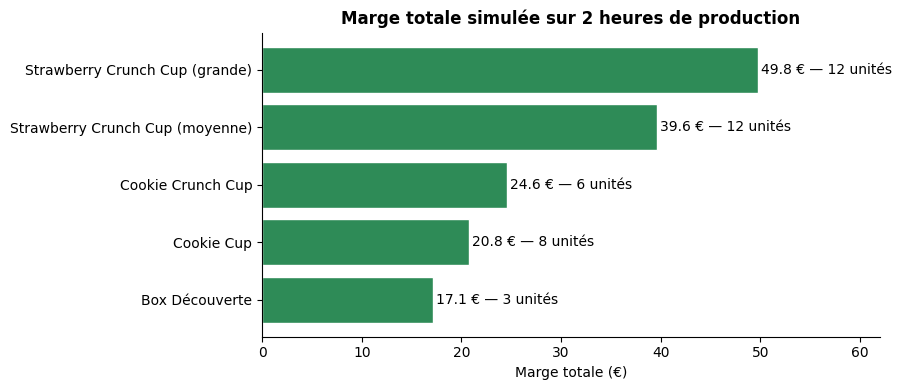

In [30]:
df_sim = df.sort_values(by="marge_totale_2h", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(df_sim["nom_produit"], df_sim["marge_totale_2h"], color="seagreen", edgecolor="white")

for idx, (val, qty) in enumerate(zip(df_sim["marge_totale_2h"], df_sim["quantite_possible"])):
    ax.text(val + 0.3, idx, f"{val:.1f} € — {int(qty)} unités", va="center", fontsize=10)

ax.set_xlabel("Marge totale (€)")
ax.set_title("Marge totale simulée sur 2 heures de production", fontweight="bold")
ax.set_xlim(0, 62)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Conclusion

Cette analyse a été réalisée avant le lancement de l'activité, dans une logique de modélisation prévisionnelle.

Les indicateurs calculés orientent vers les recommandations suivantes :
- prioriser la production des Strawberry Crunch Cups, dont la marge horaire est la plus élevée,
- maintenir les cookies comme produits complémentaires,
- positionner la Box Découverte comme offre d'appel plutôt que comme produit principal,
- adapter la production quotidienne en fonction du temps disponible.

Le modèle repose sur des estimations théoriques. Les écarts entre ces prévisions et la réalité opérationnelle seront analysés dans la **Partie II du projet**, à travers une structuration des données réelles en SQL et un suivi de l'activité.